# Isolation Forest

Entraîner un modèle Isolation Forest sur les features préparées. Tester avec différents taux de contamination. Analyser les anomalies détectées. Livrable : notebook isolation_forest.ipynb.

## Définition 

L'Isolation Forest est une méthode d'apprentissage non supervisé particulièrement efficace pour la détection d'anomalies. Alors que les autres méthodes classiques cherchent à définir ce qu'est un point normal pour identifier ce qui n'en est pas, l'algorithme Isolation Forest cherche directement à isoler les anomalies. Ainsi un point facile à isoler est considéré comme une anomalie car il est différent des autres alors qu'un point normal est difficile à isoler car il ressemble à beaucoup d'autres points.

## Principe de l'algorithme 

En principe l'algorithme construit une forêt d'arbres de décision selon le processus suivant :
    - Partitionnement aléatoire : Pour chaque arbre, on choisit une variable au hasard et on effectue une coupe à une valeur aléatoire entre le minimum et le maximum.
    -Séparation récursive : Ce processus est répété jusqu'à ce que chaque point de données soit isolé dans sa propre feuille.
    -Profondeur des feuilles :  Les anomalies se retrouvent isolées très rapidement et apparaissent donc à une faible profondeur dans l'arbre.

## Paramètres clés utilisés 

Contamination : C'est le paramètre le plus critique. Il définit la proportion attendue d'anomalies dans le jeu de données ainsi il aide l'algorithme à fixer le seuil de décision sur le score d'anomalie.

Score d'anomalie : L'algorithme calcule un score normalisé pour chaque point. Un score proche de 1 indique une anomalie probable, tandis qu'un score proche de 0 indique un point normal.

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest       # modèle Isolation Forest
from sklearn.preprocessing import StandardScaler   # normalisation
from sklearn.metrics import classification_report, confusion_matrix  # évaluation


In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,   low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS,   low_memory=False)



## Dataset 1 : CIC-IDS-2017

### 1.1 Préparation des données

On sépare les features du label et on normalise les données avant d'entraîner le modèle.

In [3]:
# séparation features et label
X_cicids = df_cicids.drop(columns=['Label']).select_dtypes(include=[np.number])
y_cicids = (df_cicids['Label'] != 'BENIGN').astype(int)  # 0 pour normal et 1 pour attaque

# nettoyage et normalisation
X_cicids = X_cicids.fillna(0).replace([np.inf, -np.inf], 0)
X_cicids_scaled = StandardScaler().fit_transform(X_cicids)

print(f"Features : {X_cicids.shape[1]}")
print(f"Proportion d'attaques réelles : {y_cicids.mean():.2%}")

Features : 79
Proportion d'attaques réelles : 57.38%


### 1.2 Test avec différents taux de contamination

Le taux de contamination indique au modèle quelle proportion de points il doit considérer comme anomalies ppur cela on va tester plusieurs valeurs pour trouver celle qui correspond le mieux.

In [11]:
taux = [0.05, 0.10, 0.20] # on test 3 taux de contamination différents
for t in taux:
    model = IsolationForest(contamination=t, random_state=42, n_jobs=-1)  # entraînement du modèle
    predictions = model.fit_predict(X_cicids_scaled)
    predictions = (predictions == -1).astype(int) # conversion de -1 (anomalie) en 1 et 1 (normal)  en 0
    print(f"\n Taux de contamination : {t:.0%} ")
    print(f"Anomalies détectées : {predictions.sum()}")
    print(classification_report(y_cicids, predictions, target_names=['Normal', 'Attaque']))


 Taux de contamination : 5% 
Anomalies détectées : 11154
              precision    recall  f1-score   support

      Normal       0.40      0.89      0.55     95066
     Attaque       0.02      0.00      0.00    128014

    accuracy                           0.38    223080
   macro avg       0.21      0.44      0.28    223080
weighted avg       0.18      0.38      0.24    223080


 Taux de contamination : 10% 
Anomalies détectées : 22307
              precision    recall  f1-score   support

      Normal       0.38      0.80      0.52     95066
     Attaque       0.17      0.03      0.05    128014

    accuracy                           0.36    223080
   macro avg       0.27      0.42      0.28    223080
weighted avg       0.26      0.36      0.25    223080


 Taux de contamination : 20% 
Anomalies détectées : 44616
              precision    recall  f1-score   support

      Normal       0.38      0.72      0.50     95066
     Attaque       0.40      0.14      0.21    128014

    ac

On remarque que les résultats sont globalement faibles sur ce dataset. Avec un taux de 5%, le modèle détecte seulement 11 154 anomalies mais ne détecte presque aucune attaque , il prédit presque tout comme normal. À 10% les performances s'améliorent légèrement avec un recall attaque à 0.03 mais c'est encore très insuffisant. À 20% on obtient les meilleurs résultats avec un recall attaque plus élevé mais une précision faible.
Ces résultats peuvent s'expliquer par le fait que les attaques DDoS ressemblent trop au trafic normal, c'est notamment ce qu'on avait observé sur la PCA avec seulement 32% d'information conservée et un chevauchement entre les classes. Le meilleur taux sera 20% car c'est celui qui donne le meilleur compromis entre précision et recall.

### 1.3 Modèle final et analyse des anomalies

On choisit le taux de contamination le plus proche de la proportion réelle d'attaques dans le dataset et on analyse les anomalies détectées.

In [9]:
model_cicids = IsolationForest(contamination=0.20, random_state=42, n_jobs=-1) #on entraîne le modèle final avec le meilleur taux trouvé ici 0,20
df_cicids['anomalie'] = (model_cicids.fit_predict(X_cicids_scaled) == -1).astype(int) # conversion  -1 en 1 et 1 en 0
df_cicids['score_anomalie'] = model_cicids.score_samples(X_cicids_scaled) #score de chaque point 
print(df_cicids.groupby('Label')['anomalie'].value_counts()) # on compte combien d'anomalies sont détectées dans chaque classe réelle


Label   anomalie
BENIGN  0            68216
        1            26850
DDoS    0           110248
        1            17766
Name: count, dtype: int64


Le modèle détecte 26 850 anomalies dans le trafic BENIGN et seulement 17 766 dans le trafic DDoS ainsi sur les 128 014 attaques réelles, 110 248 passent inaperçues (labeled 0) ce qui représente un taux de détection de seulement 14%. En parallèle le modèle classe à tort 26 850 connexions normales comme suspectes, ce sont des faux positifs.
Ce modèle n'est donc pas adapté à ce type d'attaque.

La matrice de confusion montre combien d'attaques ont été bien détectées (vrais positifs) et combien ont été ratées (faux négatifs).

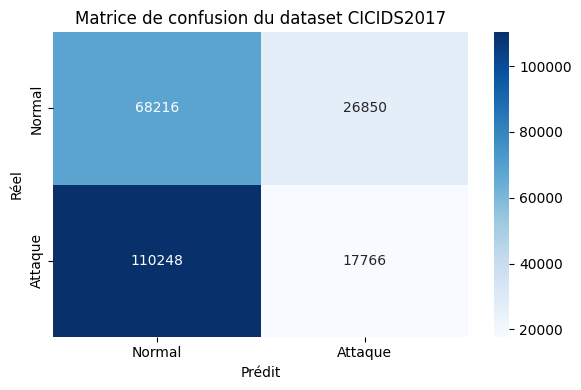

In [12]:
cm = confusion_matrix(y_cicids, df_cicids['anomalie'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Normal', 'Attaque'],yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de confusion du dataset CICIDS2017')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

La matrice confirme les résultats observés précédemment car sur les 95 066 connexions normales, le modèle en classe correctement 68 216 mais génère 26 850 faux positifs. Sur les 128 014 attaques réelles, seulement 17 766 sont détectées (vrais positifs) tandis que 110 248 passent inaperçues, ce sont les faux négatifs.Ce résultat confirme que l'Isolation Forest n'est pas adapté à ce dataset car les attaques DDoS forment un groupe trop dense et homogène pour être considérées comme des anomalies par cet algorithme.

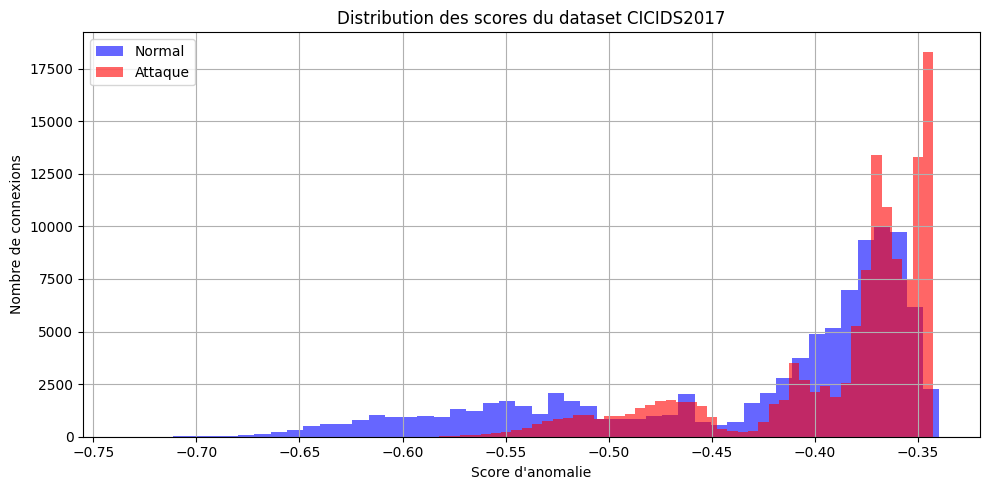

In [27]:
# Distribution des scores CICIDS 
plt.figure(figsize=(10, 5))
df_cicids[y_cicids == 0]['score_anomalie'].hist(bins=50, alpha=0.6, label='Normal', color='blue')
df_cicids[y_cicids == 1]['score_anomalie'].hist(bins=50, alpha=0.6, label='Attaque', color='red')
plt.xlabel('Score d\'anomalie')
plt.ylabel('Nombre de connexions')
plt.title('Distribution des scores du dataset CICIDS2017')
plt.legend()
plt.tight_layout()
plt.show()

Ici le modèle détecte seulement 17 766 attaques sur 128 014 car les attaques DDoS, très nombreuses et homogènes, forment un groupe dense que l'Isolation Forest perçoit comme "normal" plutôt que comme des anomalies isolées. Ainsi l'algorithme échoue face aux attaques massives et répétitives.


## Dataset 2 : UNSW-NB15

### 2.1 Préparation des données

In [13]:
# séparation features / label
X_unsw = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y_unsw = df_unsw['Label']  # 0 = normal, 1 = attaque

# nettoyage et normalisation
X_unsw = X_unsw.fillna(0).replace([np.inf, -np.inf], 0)
X_unsw_scaled = StandardScaler().fit_transform(X_unsw)

print(f"Features : {X_unsw.shape[1]}")
print(f"Proportion d'attaques réelles : {y_unsw.mean():.2%}")

Features : 44
Proportion d'attaques réelles : 3.17%


### 2.2 Test avec différents taux de contamination

In [14]:
taux = [0.03, 0.05, 0.10] # on test avec 3 taux de contamination
for t in taux:
    model = IsolationForest(contamination=t, random_state=42, n_jobs=-1)
    predictions = (model.fit_predict(X_unsw_scaled) == -1).astype(int)
    print(f"\n Taux de contamination : {t:.0%} ")
    print(f"Anomalies détectées : {predictions.sum()}")
    print(classification_report(y_unsw, predictions, target_names=['Normal', 'Attaque']))


 Taux de contamination : 3% 
Anomalies détectées : 20999
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98    677786
     Attaque       0.34      0.32      0.33     22215

    accuracy                           0.96    700001
   macro avg       0.66      0.65      0.66    700001
weighted avg       0.96      0.96      0.96    700001


 Taux de contamination : 5% 
Anomalies détectées : 35000
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97    677786
     Attaque       0.34      0.53      0.41     22215

    accuracy                           0.95    700001
   macro avg       0.66      0.75      0.69    700001
weighted avg       0.96      0.95      0.96    700001


 Taux de contamination : 10% 
Anomalies détectées : 70000
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96    677786
     Attaque       0.31      0.99      0.48     22215

    acc

Ici le trafic normal est très bien géré avec une précision et un recall autour de 0.98 pour les trois taux testés donc le modèle ne génère quasiment pas de fausses alertes sur le trafic légitime. Pour les attaques on observe une progression intéressante car à 3% le modèle détecte 32% des attaques, à 5% le recall monte à 0.53 donc une attaque sur deux est détectée avec une précision correcte et à 10% le recall est à 0.99 ce qui veut dire que presque toutes les attaques sont détectées, mais la précision chute à 0.31 ainsi le modèle génère alors beaucoup trop de fausses alertes. L'algorithme Isolation Forest fonctionne bien sur ce dataset car les attaques représentent seulement 3% du trafic et sont suffisamment différentes du trafic normal pour être facilement isolées. Le meilleur taux à retenir est 5% car il offre le meilleur compromis entre détecter un maximum d'attaques sans trop alarmer sur du trafic normal.

### 2.3 Modèle final et analyse des anomalies

In [16]:
model_unsw = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1) # modèle final avec contamination 5% 
df_unsw['anomalie'] = (model_unsw.fit_predict(X_unsw_scaled) == -1).astype(int)
df_unsw['score_anomalie'] = model_unsw.score_samples(X_unsw_scaled)

print(df_unsw.groupby('Label')['anomalie'].value_counts()) # on compte combien d'anomalies sont détectées dans chaque classe réelle


Label  anomalie
0      0           654526
       1            23260
1      1            11740
       0            10475
Name: count, dtype: int64


Sur les 677 786 connexions normales on en compte 654 526 qui sont bien classées et seulement 23 260 sont faussement signalées comme suspectes, soit un taux de faux positifs de seulement 3.4%, ce qui est très bon. Sur les 22 215 attaques réelles, 11 740 sont détectées et 10 475 passent inaperçues ainsi le modèle détecte donc un peu plus d'une attaque sur deux, ce qui correspond au recall de 0.53 observé précédemment.

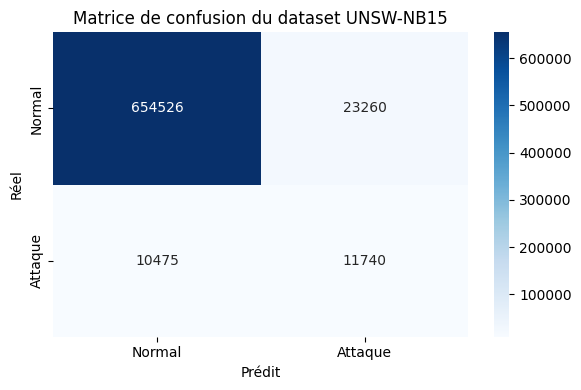

In [17]:
# Matrice de confusion 
cm = confusion_matrix(y_unsw, df_unsw['anomalie'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Normal', 'Attaque'],yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de confusion du dataset UNSW-NB15')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

La matrice confirme visuellement ce résultat car le carré bleu foncé en haut à gauche (654 526) montre que le trafic normal est très bien préservé. La case en bas à droite (11 740 vrais positifs) est moins foncée car les attaques sont minoritaires dans le dataset. Le résultat le plus important est que les deux cases du bas sont relativement équilibrées (10 475 vs 11 740), l'Isolation Forest fonctionne donc bien mieux sur UNSW-NB15 grâce à la nature plus isolable des attaques dans ce dataset.

On trace un histogramme de distribution des scores d'anomalie séparé par classe (Normal / Attaque). Il permet de voir visuellement si le modèle attribue des scores plus bas aux attaques qu'aux connexions normales.

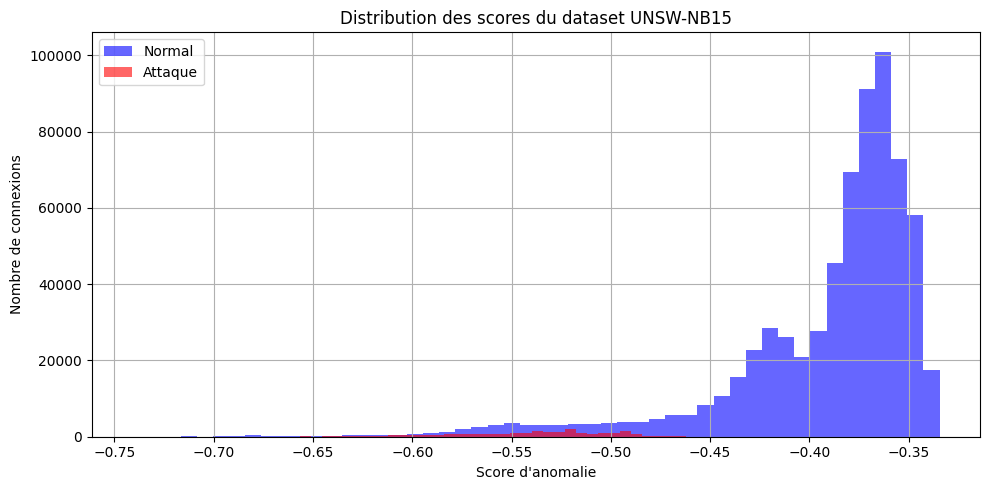

In [28]:
# Distribution des scores UNSW
plt.figure(figsize=(10, 5))
df_unsw[y_unsw == 0]['score_anomalie'].hist(bins=50, alpha=0.6, label='Normal', color='blue')
df_unsw[y_unsw == 1]['score_anomalie'].hist(bins=50, alpha=0.6, label='Attaque', color='red')
plt.xlabel('Score d\'anomalie')
plt.ylabel('Nombre de connexions')
plt.title('Distribution des scores du dataset UNSW-NB15')
plt.legend()
plt.tight_layout()
plt.show()

On remarque que les deux distributions se chevauchent entre -0.55 et -0.35, mais le modèle parvient tout de même à isoler une partie significative des attaques et ceux comme le confirme la matrice de confusion. Les attaques avec des scores très bas (vers -0.75 à -0.60) ou très haut (verd -0.40 à -0.35 ) correspondent aux cas les plus facilement isolables, probablement des attaques au comportement réseau très atypique. La séparation n'est pas parfaite, mais elle est suffisante pour que l'Isolation Forest soit utile sur ce dataset


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Préparation des données

Comme ce dataset n'a qu'une seule colonne numérique on décide d'encoder les colonnes catégorielles pour pouvoir appliquer l'Isolation Forest.

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_enc = df_logs.copy() #copie du dataframe original 
for col in ['protocol', 'action', 'log_type']: # encodage des colonnes texte en nombres
    if col in df_enc.columns:
        df_enc[col + '_enc'] = LabelEncoder().fit_transform(df_enc[col].astype(str))
features = ['bytes_transferred'] + [c for c in df_enc.columns if c.endswith('_enc')] #on garde les colonnes bytes_transferred et toutes les colonnes encodées 
X = df_enc[features].fillna(0)   # on remplace les valeurs manquantes par 0
y = df_logs['threat_label']    # labels 
X_scaled = StandardScaler().fit_transform(X) # normalisation met toutes les features à la même échelle 

print(f"Features utilisées : {features}")
print(f"Répartition des classes :\n{y.value_counts()}")

Features utilisées : ['bytes_transferred', 'protocol_enc', 'action_enc', 'log_type_enc']
Répartition des classes :
threat_label
benign        5517611
suspicious     360883
malicious      121506
Name: count, dtype: int64


### 3.2 Test avec différents taux de contamination

In [20]:
taux = [0.02, 0.05, 0.08] #on test 3 taux
for t in taux:
    model = IsolationForest(contamination=t, random_state=42, n_jobs=-1)
    predictions = (model.fit_predict(X_scaled) == -1).astype(int)    
    anomalies = (y != 'benign').astype(int)
    
    print(f"\nTaux de contamination : {t:.0%}")
    print(f"Anomalies détectées   : {predictions.sum()}")
    print(classification_report(anomalies, predictions, target_names=['Normal', 'Anomalie']))
    
    


Taux de contamination : 2%
Anomalies détectées   : 119956
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95   5517611
    Anomalie       0.11      0.03      0.04    482389

    accuracy                           0.90   6000000
   macro avg       0.52      0.50      0.50   6000000
weighted avg       0.86      0.90      0.88   6000000


Taux de contamination : 5%
Anomalies détectées   : 299825
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.94   5517611
    Anomalie       0.11      0.07      0.08    482389

    accuracy                           0.88   6000000
   macro avg       0.52      0.51      0.51   6000000
weighted avg       0.86      0.88      0.87   6000000


Taux de contamination : 8%
Anomalies détectées   : 479999
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92   5517611
    Anomalie       0.11      0.11      0.11    482389

    a

On remarque que le modèle a du mal à clairement détecter les anomalies car quel que soit le taux testé, la précision reste bloquée à 0.11 et le recall ne dépasse pas 0.11 à 8%. Ainsi sur 10 alertes levées, 9 sont de faux positifs. Le taux à 8% est objectivement le meilleur des trois puisqu'il colle au nombre réel d'anomalies avec environ 480k détectées pour 482k réelles, mais c'est trompeur car le modèle ne reconnaît pas vraiment les comportements malveillants, il se contente de sélectionner un quota prédéfini au hasard. La cause probable est que les features utilisées (bytes_transferred, protocol, action, log_type) ne sont pas assez discriminantes car un trafic malveillant peut avoir exactement les mêmes valeurs qu'un trafic bénin. 

### 3.3 Modèle final et analyse des anomalies

In [22]:
model_logs = IsolationForest(contamination=0.08, random_state=42, n_jobs=-1)
model_logs.fit(X_scaled)
df_logs['anomalie'] = (model_logs.predict(X_scaled) == -1).astype(int)
df_logs['score_anomalie'] = model_logs.score_samples(X_scaled)

print(df_logs.groupby('threat_label')['anomalie'].value_counts()) # on compte combien d'anomalies sont détectées dans chaque classe réelle


threat_label  anomalie
benign        0           5088413
              1            429198
malicious     0            111198
              1             10308
suspicious    0            320390
              1             40493
Name: count, dtype: int64


Malheureusement le modèle détecte très mal les vraies menaces avec seulement 10 308 malicious sur 121 506 sont détectés comme anomalies et 40 493 suspicious sur 360 883. La grande majorité des attaques passe donc complètement inaperçue. À l'inverse, 429 198 benignes sont faussement signalés comme anomalies , ce qui représente presque la totalité des 480k alertes levées. Le modèle se trompe de cible il isole des comportements normaux rares plutôt que des comportements malveillants.
Cela confirme que les features actuelles ne permettent pas à l'Isolation Forest de distinguer une menace d'un trafic bénin atypique. 

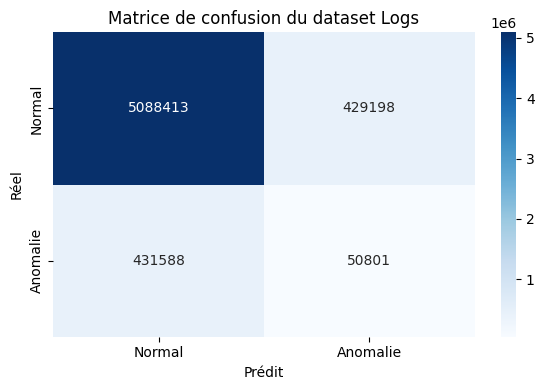

In [25]:
y_logs_bin = (df_logs['threat_label'] != 'benign').astype(int) # 3 classes donc benign en 0 et suspicious + malicious en 1

# Matrice de confusion
cm = confusion_matrix(y_logs_bin, df_logs['anomalie'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Normal', 'Anomalie'],yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice de confusion du dataset Logs')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

La matrice confirme ce qu'on avait observé avec seulement 50 801 vraies anomalies détectées sur 482 389 ce qui est extrêmement faible. Le modèle rate 89% des menaces réelles.
De même on a 429 198 connexions normales qui sont faussement signalées comme anomalies, soit presque autant que les vraies détections. Le modèle génère donc massivement de fausses alertes tout en laissant passer l'essentiel des menaces .

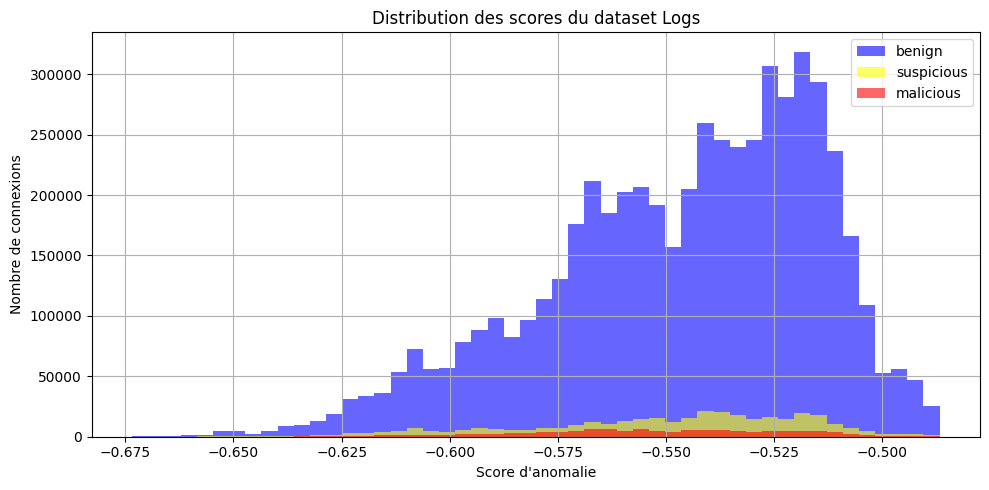

In [24]:
# Distribution des scores Logs par classe
plt.figure(figsize=(10, 5))
colors = {'benign': 'blue', 'malicious': 'red', 'suspicious': 'yellow'}
for label in df_logs['threat_label'].unique():
    df_logs[df_logs['threat_label'] == label]['score_anomalie'].hist(bins=50, alpha=0.6, label=label, color=colors.get(label, 'gray'))
plt.xlabel('Score d\'anomalie')
plt.ylabel('Nombre de connexions')
plt.title('Distribution des scores du dataset Logs')
plt.legend()
plt.tight_layout()
plt.show()

Le graphique confirme visuellement l'échec du modèle sur ce dataset car les trois classes (benign, suspicious, malicious) ont exactement la même distribution de scores, entièrement superposées entre -0.625 et -0.500. Le modèle n'attribue pas de scores plus bas aux menaces ainsi un trafic malveillant reçoit le même score qu'un trafic bénin


## Sauvegarde des résultats

In [ ]:
df_cicids.to_csv('../Data/cicids_isolation.csv', index=False)
df_unsw.to_csv('../Data/unsw_isolation.csv', index=False)
df_logs.to_csv('../Data/logs_isolation.csv', index=False)



## Bilan 

En conclusion l'Isolation Forest donne des résultats très contrastés selon les datasets. Sur UNSW-NB15, le modèle s'en sort correctement avec un recall d'environ 53%, les attaques étant suffisamment atypiques pour être isolées. Sur CICIDS2017 et les Logs en revanche, les performances sont décevantes car les attaques DDoS massives de CICIDS forment des groupes trop denses pour être perçues comme anomalies, et les Logs ne disposent pas de features assez discriminantes. Ainsi l'lagorithme Isolation Forest est efficace uniquement lorsque les anomalies sont réellement rares et isolées dans l'espace de features ce qui n'est pas toujours le cas .